# 进阶实践项目 04 参考答案：受试者级交叉验证、校准与决策曲线

本答案使用逻辑回归作为透明概率基线，并把按记录验证作为有意设置的错误对照。主结果来自受试者级分层交叉验证。树模型或 XGBoost 可以作为扩展，但必须使用相同受试者折。


> **实践定位**
>
> 这不是短时间代码竞赛，也不是以最高分数决定完成度的作业。可以只完成数据核对、基线、一个消融实验或一段严谨的失败分析。问题定义、文献依据、方法选择、验证设计、错误解释和下一步实验，重要性高于单一性能数值。
>
> 最终提交由两部分组成：当前 Notebook，以及一份设计报告。设计报告不是代码说明书，而是研究方案说明。参考答案只展示一种能够运行的方案，不代表唯一正确答案，也不意味着其中的模型一定最适合你的目标。

**参考答案不是唯一正确答案。** 其他方案只要问题定义、数据处理、验证和解释合理，同样可以成立。

## 对应题目 1：环境与数据读取

真实文件优先从 Kaggle 输入读取。演示回退保留重复测量结构。最重要的修正是受试者 ID：删除文件名最后的录音编号，而不是只取第一个下划线字段。


In [1]:
from pathlib import Path
import json
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss,confusion_matrix
from sklearn.calibration import calibration_curve
SEED=42;OUT=Path('/kaggle/working') if Path('/kaggle').exists() else Path('outputs_adv04');OUT.mkdir(exist_ok=True)

def load_data():
 paths=[]
 for root in [Path('/kaggle/input'),Path('/mnt/data')]:
  if root.exists():paths+=list(root.glob('**/parkinsons.data'))
 if paths:return pd.read_csv(paths[0]),'real'
 rng=np.random.default_rng(SEED);rows=[]
 for s in range(31):
  status=int(s<23);base=rng.normal(status*.7,1,6)
  for r in range(6+(s%2)):
   vals=base+rng.normal(0,.25,6);rows.append([f'phon_R01_S{s:02d}_{r+1}',*vals,status])
 return pd.DataFrame(rows,columns=['name']+[f'x{i}' for i in range(6)]+['status']),'demo'
df,mode=load_data();df['subject']=df['name'].str.replace(r'_\d+$','',regex=True)
X=df.drop(columns=['name','status','subject']);y=df.status.astype(int);g=df.subject
assert df.groupby('subject').status.nunique().max()==1
print(mode,df.shape,'subjects',g.nunique());display(df[['name','subject','status']].head())


demo (201, 9) subjects 31


,name,subject,status
0,phon_R01_S00_1,phon_R01_S00,1
1,phon_R01_S00_2,phon_R01_S00,1
2,phon_R01_S00_3,phon_R01_S00,1
3,phon_R01_S00_4,phon_R01_S00,1
4,phon_R01_S00_5,phon_R01_S00,1


## 对应题目 2：Pipeline 与两种验证

填补和标准化都在 Pipeline 内部。`StratifiedKFold` 按记录分层，可能让同一人跨折；`StratifiedGroupKFold` 同时尽量保持类别比例并保证受试者不跨折。


In [2]:
pipe=Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler()),('model',LogisticRegression(C=.5,max_iter=2000))])
row_cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
group_cv=StratifiedGroupKFold(5,shuffle=True,random_state=SEED)
p_row=cross_val_predict(pipe,X,y,cv=row_cv,method='predict_proba')[:,1]
p_group=cross_val_predict(pipe,X,y,groups=g,cv=group_cv,method='predict_proba')[:,1]
# 显式检查 group 折
for tr,te in group_cv.split(X,y,g): assert set(g.iloc[tr]).isdisjoint(set(g.iloc[te]))


## 对应题目 3：区分度与概率质量

ROC-AUC 衡量排序，AUPRC 受阳性比例影响并强调阳性识别，Brier 是概率与真实结果的均方误差。按记录验证和受试者验证的差值显示重复测量泄漏可能造成的乐观偏差。


In [3]:
def score(p):return {'roc_auc':float(roc_auc_score(y,p)),'auprc':float(average_precision_score(y,p)),'brier':float(brier_score_loss(y,p))}
row_metrics=score(p_row);group_metrics=score(p_group)
print('row',row_metrics);print('subject',group_metrics)


row {'roc_auc': 0.9910944759938048, 'auprc': 0.9969372137408743, 'brier': 0.041006581886618106}
subject {'roc_auc': 0.9705730511099638, 'auprc': 0.9896265852885533, 'brier': 0.06505445549932222}


## 对应题目 4：校准与决策曲线

校准曲线把预测概率分箱后比较平均预测与真实频率。样本量很小时曲线会非常不稳定。决策曲线的净收益使用假阳性代价与阈值关系；本数据没有真实临床决策流程，因此只用于理解方法。


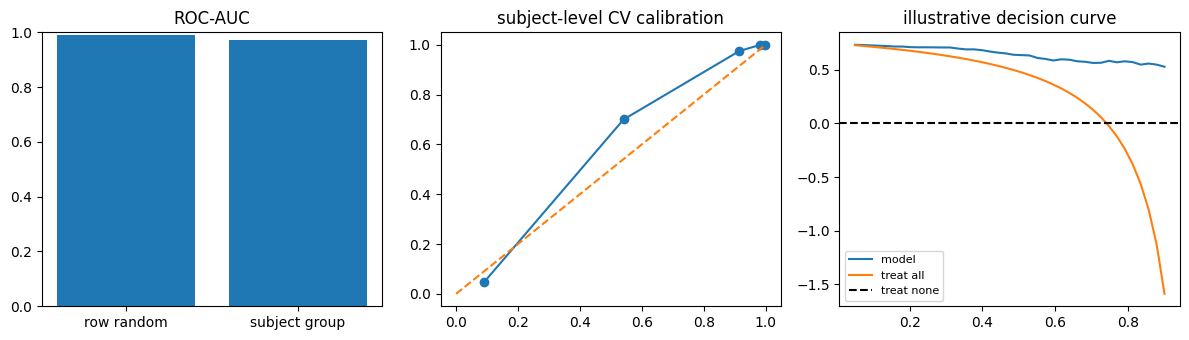

In [4]:
pt,pp=calibration_curve(y,p_group,n_bins=5,strategy='quantile')
ths=np.linspace(.05,.90,40);n=len(y);prev=y.mean();nb=[]
for t in ths:
 pred=p_group>=t;tp=((pred)&(y.values==1)).sum();fp=((pred)&(y.values==0)).sum();nb.append(tp/n-fp/n*t/(1-t))
fig,ax=plt.subplots(1,3,figsize=(12,3.5))
ax[0].bar(['row random','subject group'],[row_metrics['roc_auc'],group_metrics['roc_auc']]);ax[0].set_ylim(0,1);ax[0].set_title('ROC-AUC')
ax[1].plot(pp,pt,'o-');ax[1].plot([0,1],[0,1],'--');ax[1].set_title('subject-level CV calibration')
ax[2].plot(ths,nb,label='model');ax[2].plot(ths,[prev-(1-prev)*t/(1-t) for t in ths],label='treat all');ax[2].axhline(0,color='k',ls='--',label='treat none');ax[2].legend(fontsize=8);ax[2].set_title('illustrative decision curve')
plt.tight_layout();plt.savefig(OUT/'adv04_evaluation.png',dpi=150);plt.show()


## 对应题目 5：阈值结果与保存

0.5 仅作为示例阈值。正式阈值应根据漏诊与误报后果确定，并在独立数据中验证。


In [5]:
threshold=.5;cm=confusion_matrix(y,p_group>=threshold)
metrics={'mode':mode,'rows':len(df),'subjects':int(g.nunique()),'row_cv':row_metrics,'subject_cv':group_metrics,'threshold':threshold,'confusion_matrix':cm.tolist()}
print(metrics);json.dump(metrics,open(OUT/'adv04_result.json','w'),ensure_ascii=False,indent=2)


{'mode': 'demo', 'rows': 201, 'subjects': 31, 'row_cv': {'roc_auc': 0.9910944759938048, 'auprc': 0.9969372137408743, 'brier': 0.041006581886618106}, 'subject_cv': {'roc_auc': 0.9705730511099638, 'auprc': 0.9896265852885533, 'brier': 0.06505445549932222}, 'threshold': 0.5, 'confusion_matrix': [[45, 7], [14, 135]]}


## 如何对应题目阅读本答案

- 受试者 ID 与数据审计：第 1 部分；
- 随机记录和受试者分组：第 2 部分；
- ROC-AUC、AUPRC、Brier：第 3 部分；
- 校准与决策价值：第 4 部分；
- 阈值与误判：第 5 部分。

逻辑回归不是唯一答案。任何复杂模型都应先证明其在受试者级验证中稳定改善，并报告校准、适用人群和外部验证需求。

完整的示范研究说明见同目录 `项目04_参考设计报告.md`。其中包括研究问题、数据独立性、文献依据、方法选择、评价、结果解释、局限、下一步实验和本包运行记录。它仍然只是一种参考方案。